# Linear Regression from Scratch


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Exploration


In [2]:
df = pd.read_excel("data/real_estate_valuation.xlsx", sheet_name="工作表1")

In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## Data Preprocessing


In [6]:
# Reformat the X1 transaction date


def decimal_year_to_datetime_month_based(decimal_year):
    year = int(decimal_year)
    # The decimal part multiplied by 12 gives us the month (0-indexed)
    month_decimal = (decimal_year - year) * 12
    # Round to nearest month and add 1 (since months are 1-indexed)
    month = int(month_decimal) + 1
    # Approximate days
    day = int((month_decimal - int(month_decimal)) * 30)
    return pd.Timestamp(f"{year}-{month:02d}-{max(1, day):02d}")


df["X1 transaction date"] = df["X1 transaction date"].apply(
    decimal_year_to_datetime_month_based
)
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012-12-01,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012-12-01,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013-07-29,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013-07-01,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012-10-29,5.0,390.56840,5,24.97937,121.54245,43.1


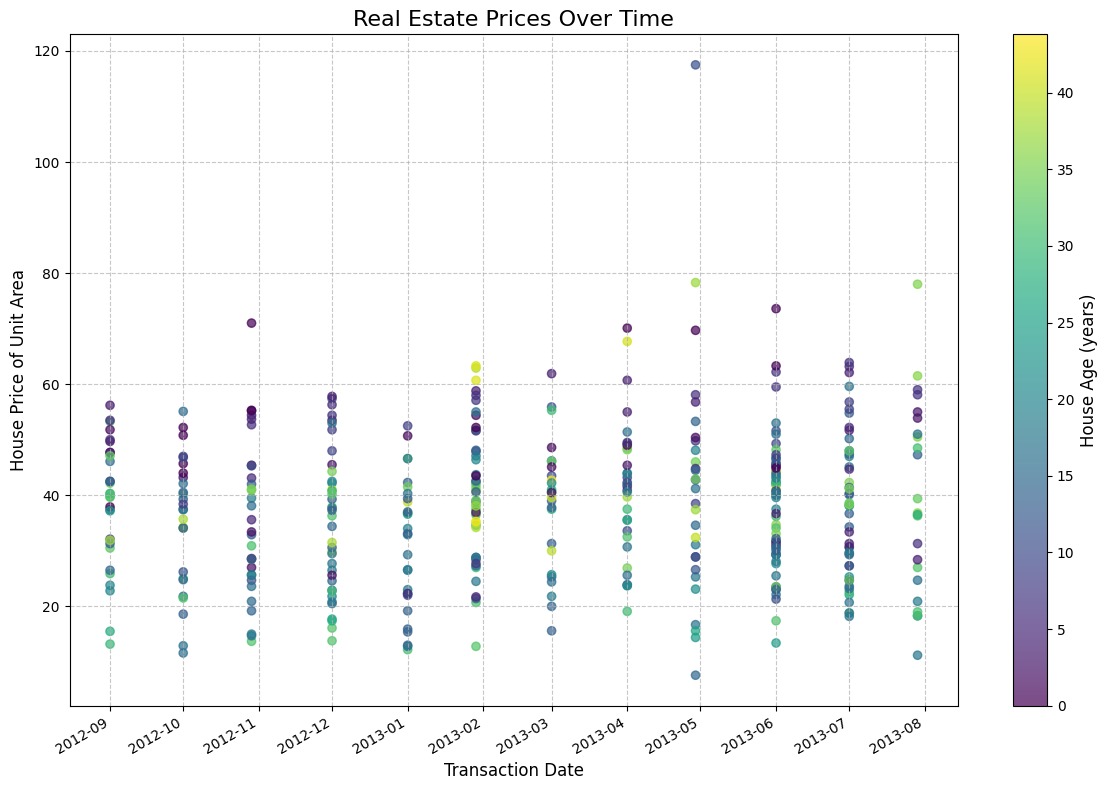

In [7]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df["X1 transaction date"],
    df["Y house price of unit area"],
    alpha=0.7,
    c=df["X2 house age"],  # Color points by house age
)

# Add a colorbar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label("House Age (years)", fontsize=12)

plt.xlabel("Transaction Date", fontsize=12)
plt.ylabel("House Price of Unit Area", fontsize=12)
plt.title("Real Estate Prices Over Time", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.gcf().autofmt_xdate()  # Rotate date labels
plt.tight_layout()
plt.show()

## Build Loss Function & Gradient Descent


In [8]:
# y = ax + b
# loss = sum((y - (ax + b))^2) / n

# We will create the loss function and gradient descent to find optimal parameters of a and b
# The input data will be `X2 house age` and `Y house price of unit area`


def loss_function(a, b, points):
    """
    Calculate the mean squared error for linear regression.

    Parameters:
      a (float): Slope of the line
      b (float): Y-intercept of the line
      points (DataFrame): DataFrame containing the data points

    Returns:
      float: Mean squared error

    Notes:
      Slope and Y-intercept of the line represent parameters that are adjusted to minimize the error between predicted and actual values.
    """

    total_errors = 0

    for i in range(len(points)):
        x = points.iloc[i]["X2 house age"]
        y = points.iloc[i]["Y house price of unit area"]
        y_pred = a * x + b
        total_errors += (y - y_pred) ** 2

    return total_errors / float(len(points))


def gradient_descent(current_a, current_b, points, learning_rate):
    """
    Gradient descent to find the optimal values of a and b.

    Parameters:
      current_a (float): Current slope of the line
      current_b (float): Current Y-intercept of the line
      points (DataFrame): DataFrame containing the data points
      learning_rate (float): Step size for updating parameters

    Returns:
      tuple: Updated values of a and b after one iteration of gradient descent
    """

    a_gradient = 0
    b_gradient = 0
    n = len(points)

    for i in range(n):
        x = points.iloc[i]["X2 house age"]
        y = points.iloc[i]["Y house price of unit area"]

        a_gradient += (-2 / n) * x * (y - (current_a * x + current_b))
        b_gradient += (-2 / n) * (y - (current_a * x + current_b))

    new_a = current_a - (learning_rate * a_gradient)
    new_b = current_b - (learning_rate * b_gradient)

    return new_a, new_b

In [9]:
a = 0
b = 0
learning_rate = 0.0001
epochs = 1000
loss_history = []

for i in range(epochs):
    a, b = gradient_descent(a, b, df, learning_rate)

    if i % 100 == 0:
        loss = loss_function(a, b, df)
        loss_history.append(loss)
        print(f"Epoch {i}: a = {a}, b = {b}, loss = {loss}")

print(f"Final parameters: a = {a}, b = {b}, loss = {loss_function(a, b, df)}")

Epoch 0: a = 0.12803299033816434, b = 0.007596038647342989, loss = 1469.9827383910877
Epoch 100: a = 1.433115758012723, b = 0.30665162642379185, loss = 694.9661827797256
Epoch 200: a = 1.423437112932959, b = 0.5516932626207012, loss = 688.9524281635747
Epoch 300: a = 1.4136949565951762, b = 0.795304828412711, loss = 683.008434219486
Epoch 400: a = 1.404009454313572, b = 1.0374994324801243, loss = 677.1333854003454
Epoch 500: a = 1.3943802875408076, b = 1.2782853169885653, loss = 671.326482003074
Epoch 600: a = 1.3848071286036479, b = 1.5176706757242362, loss = 665.5869336004492
Epoch 700: a = 1.3752896517337558, b = 1.7556636548143258, loss = 659.9139589335132
Epoch 800: a = 1.365827533057619, b = 1.9922723530042528, loss = 654.3067858052245
Epoch 900: a = 1.3564204505855268, b = 2.2275048219332643, loss = 648.7646509753547
Final parameters: a = 1.3471613380663614, b = 2.4590371705053466, loss = 643.3412628159224


## Plot the convergence of loss


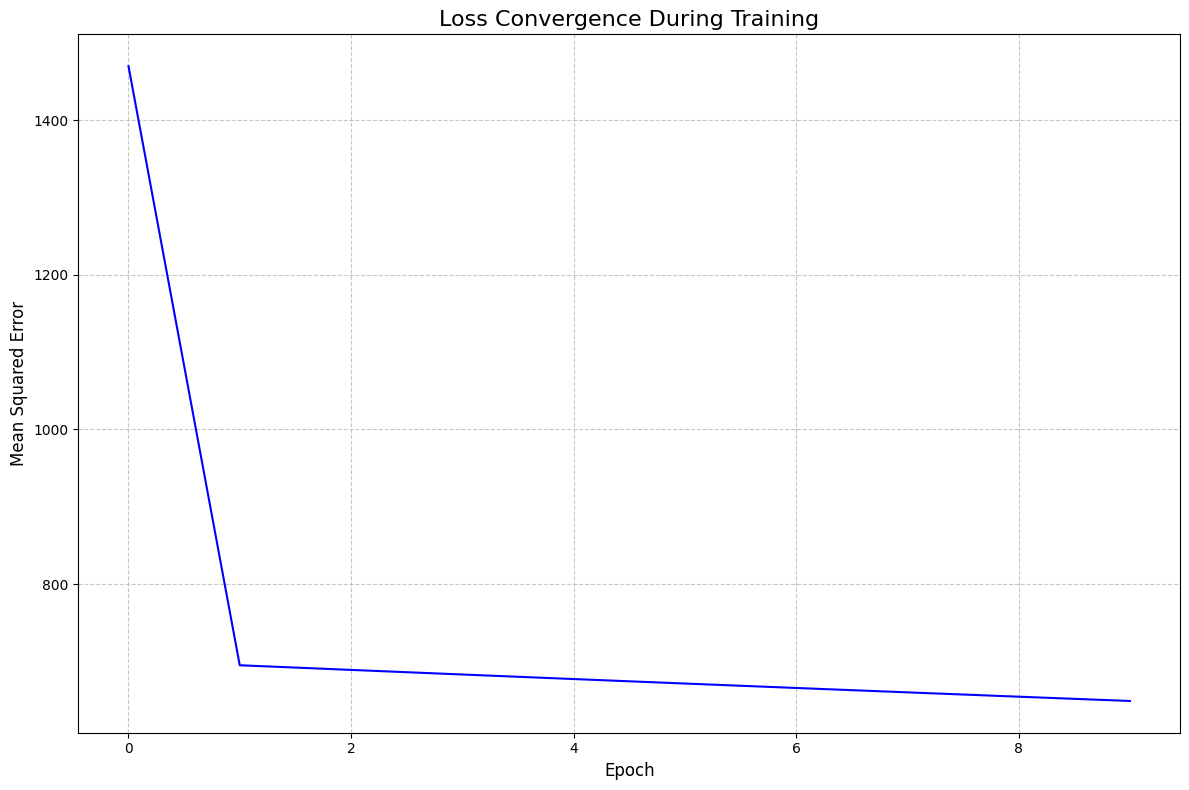

In [10]:
plt.figure(figsize=(12, 8))
plt.plot(loss_history, "b-")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean Squared Error", fontsize=12)
plt.title("Loss Convergence During Training", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Plot the Regression Line


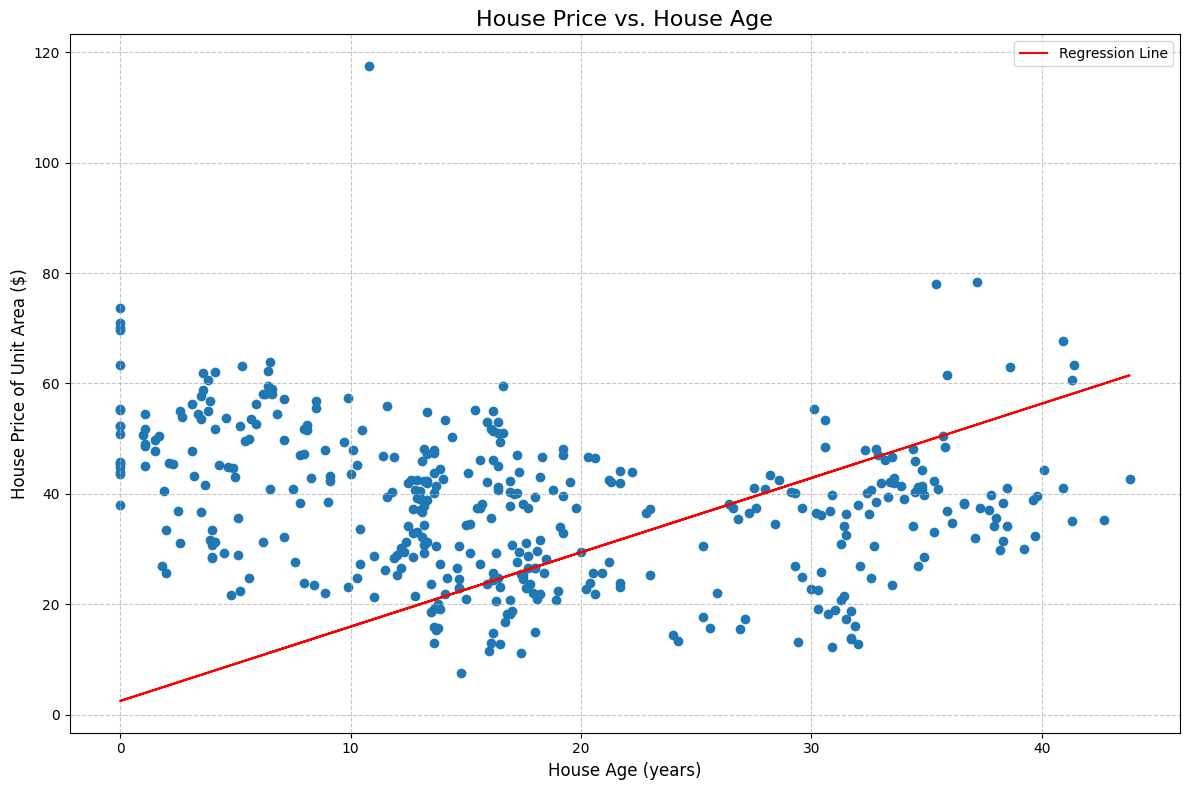

In [11]:
plt.figure(figsize=(12, 8))
plt.scatter(df["X2 house age"], df["Y house price of unit area"])
plt.plot(
    df["X2 house age"],
    a * df["X2 house age"] + b,  # y = ax + b
    color="red",
    label="Regression Line",
)
plt.xlabel("House Age (years)", fontsize=12)
plt.ylabel("House Price of Unit Area ($)", fontsize=12)
plt.title("House Price vs. House Age", fontsize=16)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()